In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sidrakshe
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri


100%|██████████| 86.8M/86.8M [00:00<00:00, 1.36GB/s]

In [ ]:
!ls /content


brain-tumor-classification-mri	sample_data


In [ ]:
!ls '/content/brain-tumor-classification-mri'


Testing  Training


In [ ]:
data_dir = '/content/brain-tumor-classification-mri/Training'


Load and Preprocess the Data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2612 images belonging to 2 classes.
Found 652 images belonging to 2 classes.


Build the CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - accuracy: 0.8598 - loss: 0.4300 - val_accuracy: 0.8804 - val_loss: 0.2597
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.8782 - loss: 0.2827 - val_accuracy: 0.8804 - val_loss: 0.3299
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8831 - loss: 0.2511 - val_accuracy: 0.8819 - val_loss: 0.3028
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.8797 - loss: 0.2569 - val_accuracy: 0.9018 - val_loss: 0.2620
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8895 - loss: 0.2170 - val_accuracy: 0.8988 - val_loss: 0.2907
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9009 - loss: 0.2126 - val_accuracy: 0.9034 - val_loss: 0.2877
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.8906 - loss: 0.2196 - val_accuracy: 0.9141 - val_loss: 0.2856
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.8871 - loss: 0.2029 - val_accuracy: 0.9064 - val_loss: 

Visualize Accuracy

In [ ]:
!ls /content


brain-tumor-classification-mri	download.jpg  sample_data
brain_tumor_model.h5		drive


new

In [ ]:
!ls /content/brain-tumor-classification-mri


Testing  Training


In [ ]:
!ls /content/brain-tumor-classification-mri/Training


glioma_tumor  meningioma_tumor	no_tumor  pituitary_tumor


In [ ]:
!ls /content/brain-tumor-classification-mri/Testing


glioma_tumor  meningioma_tumor	no_tumor  pituitary_tumor


In [ ]:
import os

base_path = '/content/brain-tumor-classification-mri'

for folder in ['Training', 'Testing']:
    print(f"\n📂 {folder} folder:")
    for category in os.listdir(os.path.join(base_path, folder)):
        count = len(os.listdir(os.path.join(base_path, folder, category)))
        print(f"{category}: {count} images")



📂 Training folder:
glioma_tumor: 826 images
pituitary_tumor: 827 images
meningioma_tumor: 822 images
no_tumor: 395 images

📂 Testing folder:
glioma_tumor: 100 images
pituitary_tumor: 74 images
meningioma_tumor: 115 images
no_tumor: 105 images


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Base directories
train_dir = '/content/brain-tumor-classification-mri/Training'
test_dir = '/content/brain-tumor-classification-mri/Testing'

# Create an ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)

# Create training generator
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    classes=['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'],
    class_mode='categorical',
    shuffle=True
)

# Create testing generator
test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    classes=['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'],
    class_mode='categorical',
    shuffle=False
)


Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 123ms/step - accuracy: 0.2833 - loss: -20097.7031 - val_accuracy: 0.2538 - val_loss: -450570.0000
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.2785 - loss: -2252690.7500 - val_accuracy: 0.2538 - val_loss: -12421016.0000
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.2701 - loss: -31632242.0000 - val_accuracy: 0.2538 - val_loss: -78113672.0000
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.2850 - loss: -154350000.0000 - val_accuracy: 0.2538 - val_loss: -282707904.0000
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.2758 - loss: -493210464.0000 - val_accuracy: 0.2538 - val_loss: -745476928.0000
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2839 - loss: -1213966720.0000 - val_accuracy: 0.2538 - val_loss: -1618606848.0000
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.2771 - loss: -2516579072.0000 - val_accuracy: 0.2538 - val_loss: -3080586

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

class_labels = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

img = image.load_img('/content/no tumor.jpg', target_size=(150, 150))
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0) / 255.0

predictions = model.predict(img)[0]
predicted_idx = np.argmax(predictions)
predicted_class = class_labels[predicted_idx]
confidence = predictions[predicted_idx]

if predicted_class == 'no_tumor':
    print(f"❌ Result: No Tumor Detected ({confidence*100:.2f}% confidence)")
else:
    print(f"✅ Result: Tumor Detected ({predicted_class}) ({confidence*100:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
✅ Tumor Detected


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

class_labels = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

y_true = test_generator.classes
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_labels))


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step
[[  0 105   0   0]
 [  0 100   0   0]
 [  0 115   0   0]
 [  0  74   0   0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.25      1.00      0.40       100
           2       0.00      0.00      0.00       115
           3       0.00      0.00      0.00        74

    accuracy                           0.25       394
   macro avg       0.06      0.25      0.10       394
weighted avg       0.06      0.25      0.10       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


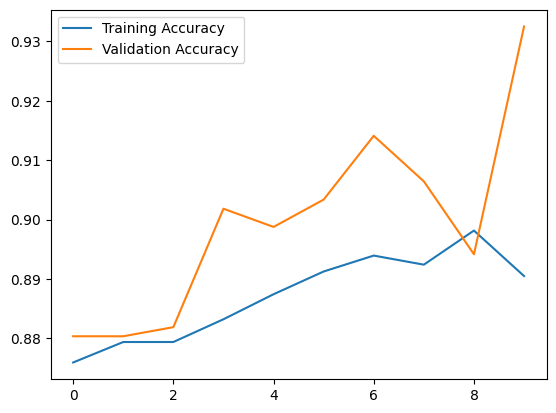

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


Test the Model on New MRI Images

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving download.jpg to download.jpg


Load and Preprocess the Image

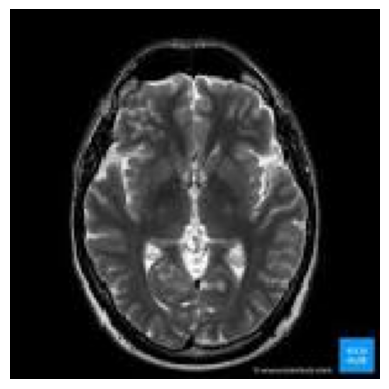

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Replace this with your uploaded file name
img_path = '/content/download.jpg'   # 👈 change this if your file name is different

# Load and preprocess
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Show the image
plt.imshow(img)
plt.axis('off')
plt.show()


Predict Tumor / No Tumor

In [ ]:
class_labels = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

prediction = model.predict(img_array)[0]
predicted_idx = np.argmax(prediction)
predicted_class = class_labels[predicted_idx]
confidence = prediction[predicted_idx]

if predicted_class == 'no_tumor':
    print(f"✅ Prediction: No Tumor Detected ({confidence*100:.2f}% confidence)")
else:
    print(f"🧠 Prediction: Tumor Detected ({predicted_class}) ({confidence*100:.2f}% confidence)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
🧠 Prediction: Tumor Detected


(Optional): See Prediction Confidence

In [ ]:
print(f"Prediction Confidence: {float(np.max(prediction)):.4f}")


Prediction Confidence: 0.7943


In [ ]:
# Save model as an .h5 file
model.save('/content/brain_tumor_model.h5')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/brain_tumor_model.h5 /content/drive/MyDrive/


Mounted at /content/drive
